## Module 2: EDA & Diagnostic Tools for Time Series
### Dataset: AirPassengers

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pandas.plotting import lag_plot

# Set global plotting dimensions and style
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style("whitegrid")

## 2. Load Data & Time Index Setup

In [2]:
path = "../data/airline-passengers.csv"
df = pd.read_csv(path)
df.head()

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [3]:
# Convert to datetime and set uniform monthly frequency
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df = df.asfreq('MS')
print(df.shape)
df.head()

(144, 1)


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


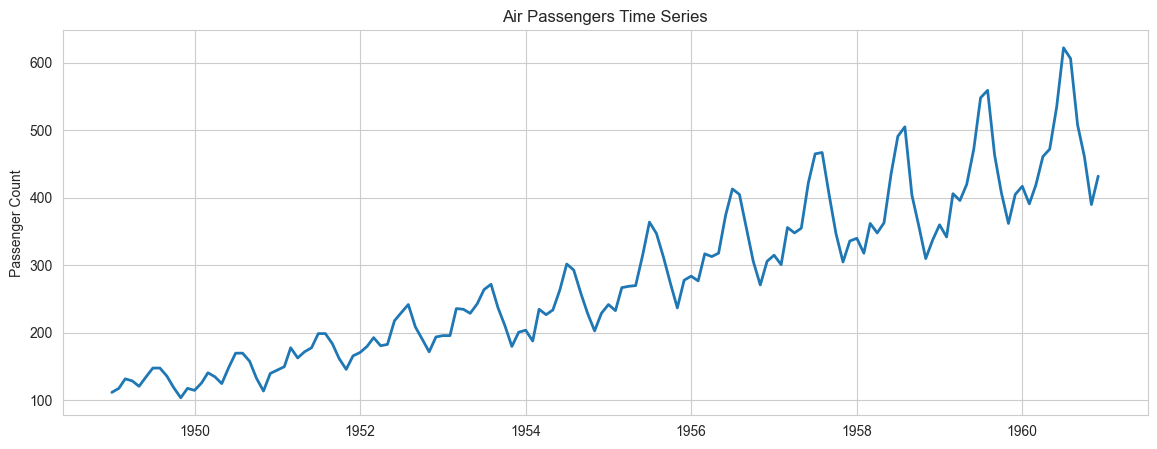

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df, color='tab:blue', linewidth=2)
plt.title("Air Passengers Time Series")
plt.ylabel("Passenger Count")
plt.show()

In [5]:

# Save a pristine copy of ground truth numbers for final diagnostics
df_ground_truth = df.copy()

In [6]:
# Make a copy to inject missing values into
df_missing = df.copy()

## 3. Simulating  Missing  Value 

In [7]:
# A. Random Intermittent Missingness
np.random.seed(42)
random_indices = np.random.choice(df_missing.index, size=5, replace=False)
df_missing.loc[random_indices, 'Passengers'] = np.nan
print(df_missing.isna().sum())

Passengers    5
dtype: int64


In [8]:
# B. Structural Missingness / Gaps (A multi-month block data loss)
structural_gap = pd.date_range(start='1954-03-01', end='1954-06-01', freq='MS')
df_missing.loc[structural_gap, 'Passengers'] = np.nan
print(df_missing.isna().sum())

Passengers    9
dtype: int64


In [9]:
# C. Systemic Point Missingness (Every December)
december_indices = df_missing.index[df_missing.index.month == 12]
df_missing.loc[december_indices, 'Passengers'] = np.nan
print(df_missing.isna().sum())


Passengers    21
dtype: int64


## 4. Diagnosing and Visualizing Missing Value Structures

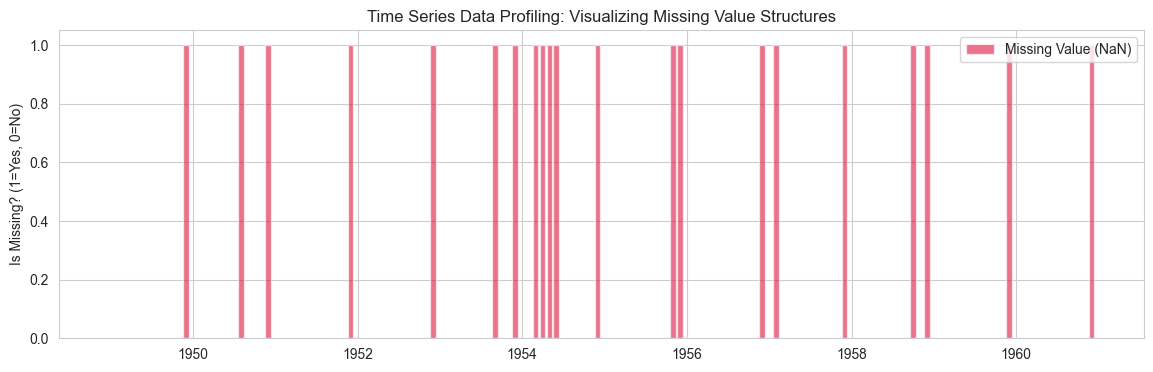

In [10]:
plt.figure(figsize=(14, 4))
plt.bar(df_missing.index, df_missing['Passengers'].isna(), width=25, color='crimson', alpha=0.6, label='Missing Value (NaN)')
plt.title("Time Series Data Profiling: Visualizing Missing Value Structures")
plt.ylabel("Is Missing? (1=Yes, 0=No)")
plt.legend()
plt.show()

### 5. Applying  and Evaluating Imputation Strategies

In [11]:
# Strategy 1: Forward-Fill (Propagates the last valid observation forward)
df_missing['Forward_Fill'] = df_missing['Passengers'].ffill()

# Strategy 2: Linear Interpolation (Draws a straight line through gaps)
df_missing['Linear_Interpolation'] = df_missing['Passengers'].interpolate(method='linear')

# Strategy 3: Moving Average Imputation (Fills gaps using a localized rolling window mean)
rolling_window_mean = df_missing['Passengers'].rolling(window=6, min_periods=1, center=True).mean()
df_missing['Moving_Average_Impute'] = df_missing['Passengers'].fillna(rolling_window_mean)

# Print a snapshot of the structural gap for verification
print("--- Imputation Value Inspection Matrix (Structural Gap) ---")
print(df_missing.loc['1954-02-01':'1954-07-01', ['Passengers', 'Forward_Fill', 'Linear_Interpolation', 'Moving_Average_Impute']])

--- Imputation Value Inspection Matrix (Structural Gap) ---
            Passengers  Forward_Fill  Linear_Interpolation  \
Month                                                        
1954-02-01       188.0         188.0                 188.0   
1954-03-01         NaN         188.0                 210.8   
1954-04-01         NaN         188.0                 233.6   
1954-05-01         NaN         188.0                 256.4   
1954-06-01         NaN         188.0                 279.2   
1954-07-01       302.0         302.0                 302.0   

            Moving_Average_Impute  
Month                              
1954-02-01                  188.0  
1954-03-01                  196.0  
1954-04-01                  196.0  
1954-05-01                  245.0  
1954-06-01                  297.5  
1954-07-01                  302.0  


## 6. Visual Imputation Comparision

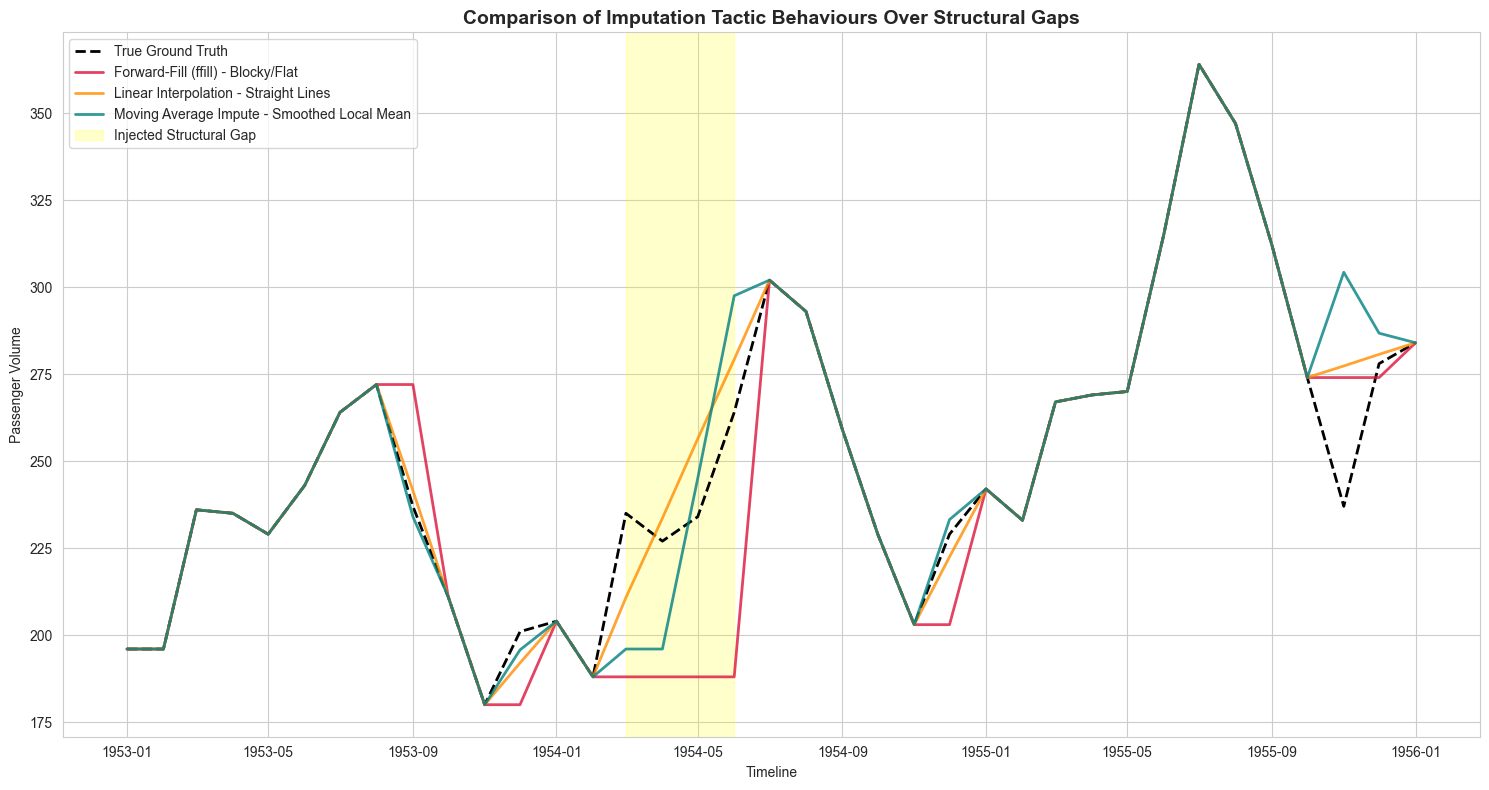

In [12]:
zoom_range = slice('1953-01-01', '1956-01-01')
plt.figure(figsize=(15, 8))

# Plot the underlying ground truth data
plt.plot(df_ground_truth.loc[zoom_range].index, df_ground_truth.loc[zoom_range, 'Passengers'], 
         label='True Ground Truth', color='black', linewidth=2, linestyle='--')

# Plot Imputation variations
plt.plot(df_missing.loc[zoom_range].index, df_missing.loc[zoom_range, 'Forward_Fill'], 
         label='Forward-Fill (ffill) - Blocky/Flat', color='crimson', alpha=0.8, linewidth=2)

plt.plot(df_missing.loc[zoom_range].index, df_missing.loc[zoom_range, 'Linear_Interpolation'], 
         label='Linear Interpolation - Straight Lines', color='darkorange', alpha=0.8, linewidth=2)

plt.plot(df_missing.loc[zoom_range].index, df_missing.loc[zoom_range, 'Moving_Average_Impute'], 
         label='Moving Average Impute - Smoothed Local Mean', color='teal', alpha=0.8, linewidth=2)

# Highlight where the structural gap was injected
plt.axvspan('1954-03-01', '1954-06-01', color='yellow', alpha=0.2, label='Injected Structural Gap')

plt.title("Comparison of Imputation Tactic Behaviours Over Structural Gaps", fontsize=14, fontweight='bold')
plt.xlabel("Timeline")
plt.ylabel("Passenger Volume")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 7. Core Vector Isolation For Diagnostics

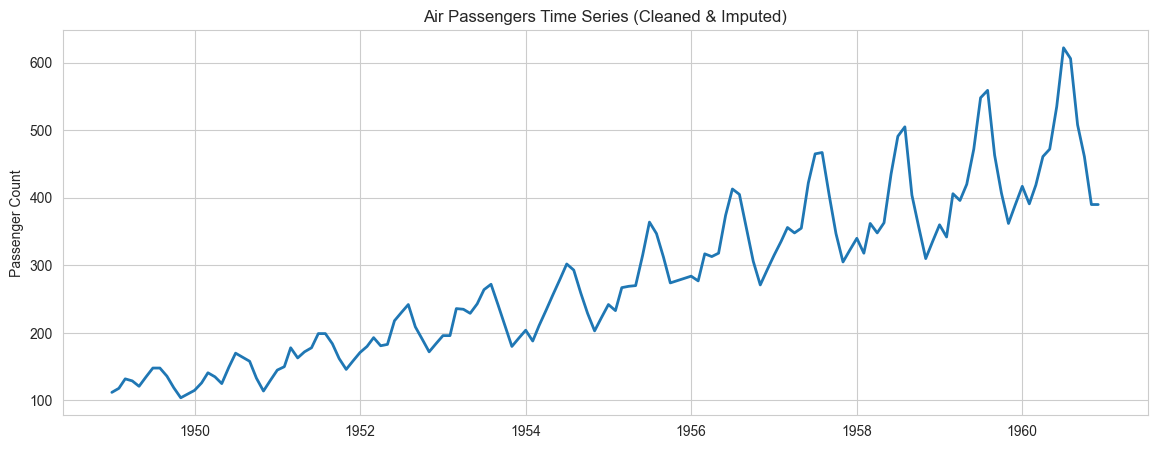

In [13]:
# We continue modeling diagnostics using our pristine imputed array sequence 
# to keep code robust and prevent categorical dataframe column errors.
df_diagnostics = df_ground_truth.copy()
df_diagnostics['Passengers'] = df_missing['Linear_Interpolation'] # Select the best-performing option for modeling
series = df_diagnostics['Passengers']

# --- Primary Time Series Visualization ---
plt.figure(figsize=(14, 5))
plt.plot(series, color='tab:blue', linewidth=2)
plt.title("Air Passengers Time Series (Cleaned & Imputed)")
plt.ylabel("Passenger Count")
plt.show()

## 8. Distribution Analysis

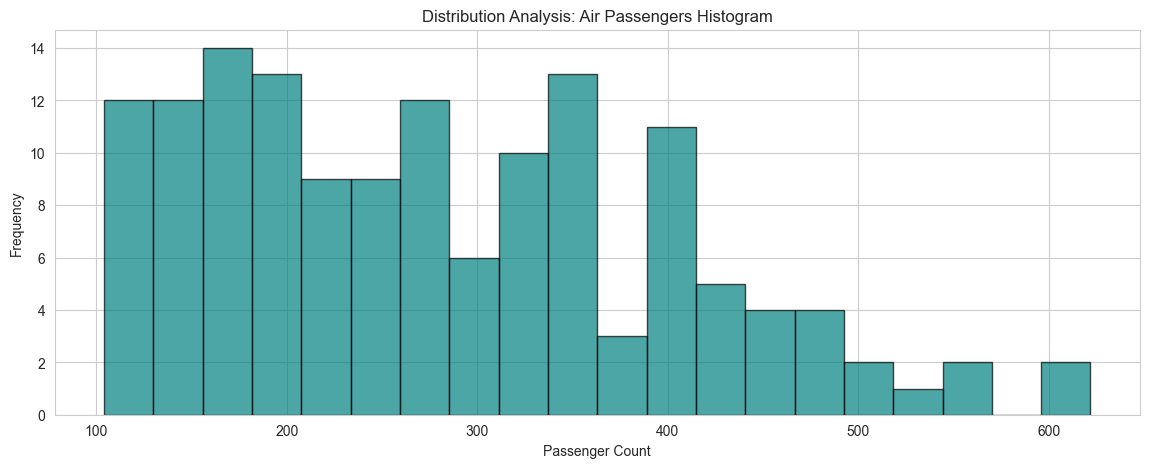

In [14]:
plt.figure(figsize=(14, 5))
plt.hist(series, bins=20, edgecolor='black', alpha=0.7, color='teal')
plt.title("Distribution Analysis: Air Passengers Histogram")
plt.xlabel("Passenger Count")
plt.ylabel("Frequency")
plt.show()

### A. KDE Plot (Non‑Parametric Distribution)

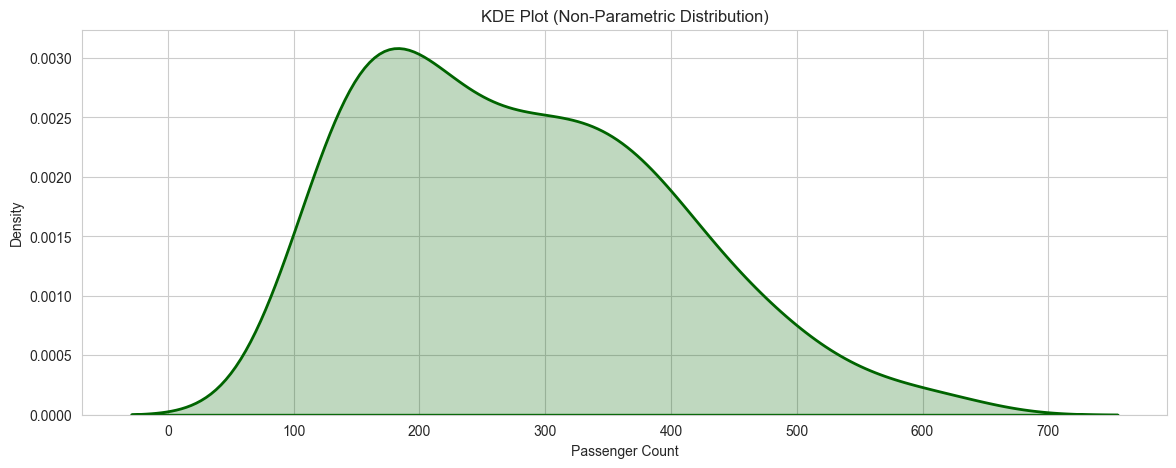

In [15]:
# KDE Plot (Non-Parametric)
plt.figure(figsize=(14, 5))
sns.kdeplot(series, fill=True, color='darkgreen', linewidth=2)
plt.title("KDE Plot (Non-Parametric Distribution)")
plt.xlabel("Passenger Count")
plt.ylabel("Density")
plt.show()

### B. Q‑Q Plot (Parametric Normality Check)

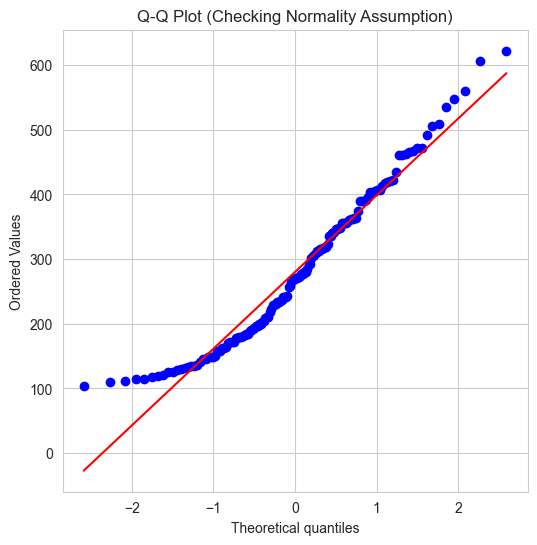

In [16]:
import scipy.stats as stats

# Q-Q Plot for Normality Check
plt.figure(figsize=(6, 6))
stats.probplot(series, dist="norm", plot=plt)
plt.title("Q-Q Plot (Checking Normality Assumption)")
plt.show()


### C. Normality Tests (Shapiro, D’Agostino K²)

In [17]:
from scipy.stats import shapiro, normaltest

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = shapiro(series)
print("Shapiro-Wilk Test:")
print(f"Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# D’Agostino K² Test
k2_stat, k2_p = normaltest(series)
print("\nD’Agostino K² Test:")
print(f"Statistic = {k2_stat:.4f}, p-value = {k2_p:.4f}")


Shapiro-Wilk Test:
Statistic = 0.9536, p-value = 0.0001

D’Agostino K² Test:
Statistic = 8.2771, p-value = 0.0159


### D. Skewness & Kurtosis (Distribution Shape Metrics)

In [18]:
# Skewness & Kurtosis
skew_val = series.skew()
kurt_val = series.kurt()

print("\nDistribution Shape Metrics:")
print(f"Skewness  = {skew_val:.4f}")
print(f"Kurtosis  = {kurt_val:.4f}")



Distribution Shape Metrics:
Skewness  = 0.5708
Kurtosis  = -0.3523


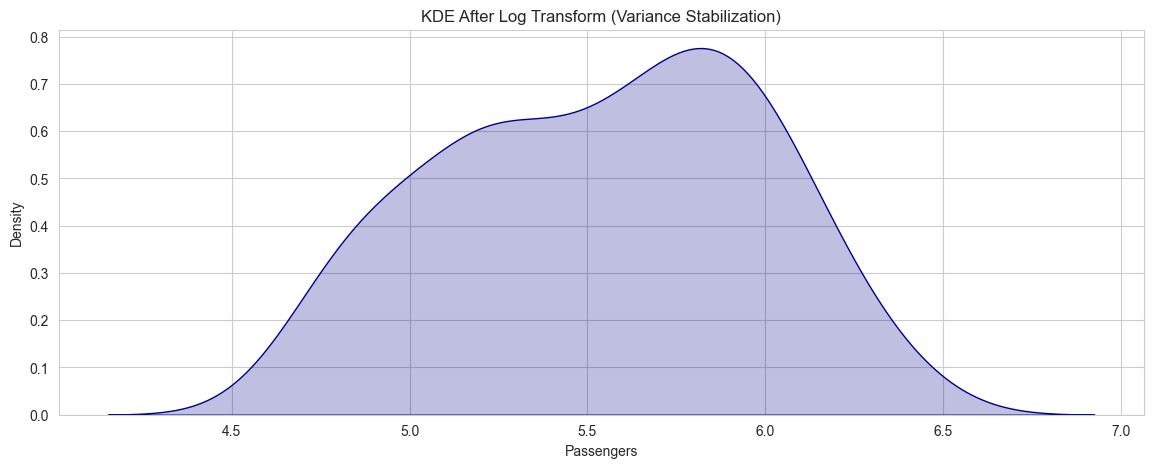

Optimal Box-Cox Lambda: 0.1720


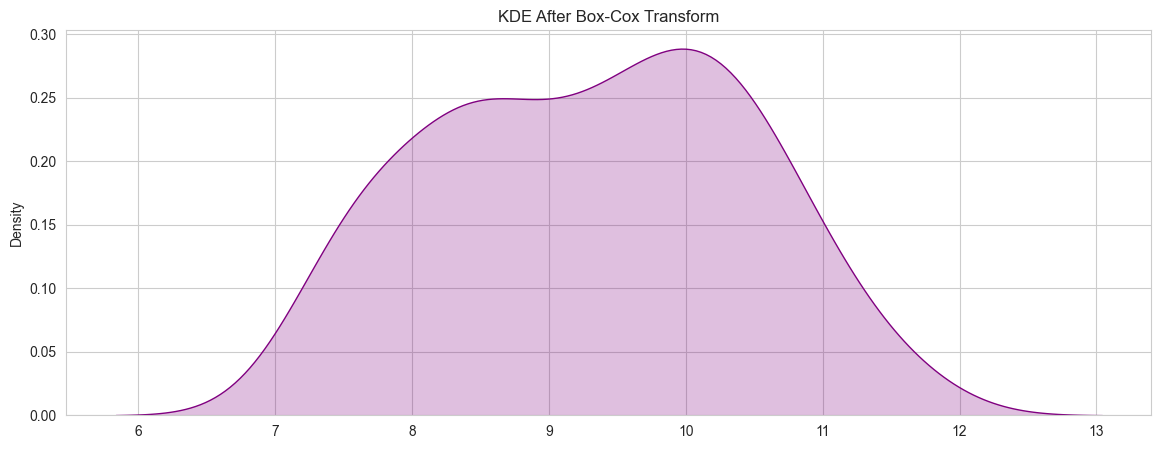

In [19]:
# --- Variance Stabilization: Log & Box-Cox Transformations ---

# Log Transform
series_log = np.log(series)

plt.figure(figsize=(14, 5))
sns.kdeplot(series_log, fill=True, color='darkblue')
plt.title("KDE After Log Transform (Variance Stabilization)")
plt.show()

# Box-Cox Transform
from scipy.stats import boxcox
series_boxcox, lambda_bc = boxcox(series)

print(f"Optimal Box-Cox Lambda: {lambda_bc:.4f}")

plt.figure(figsize=(14, 5))
sns.kdeplot(series_boxcox, fill=True, color='purple')
plt.title("KDE After Box-Cox Transform")
plt.show()


## 9. Outlier Detection & Annual Variations

C:\Users\oadsa\AppData\Local\Temp\ipykernel_11392\1924737232.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Passengers', data=df_diagnostics, palette="Blues")


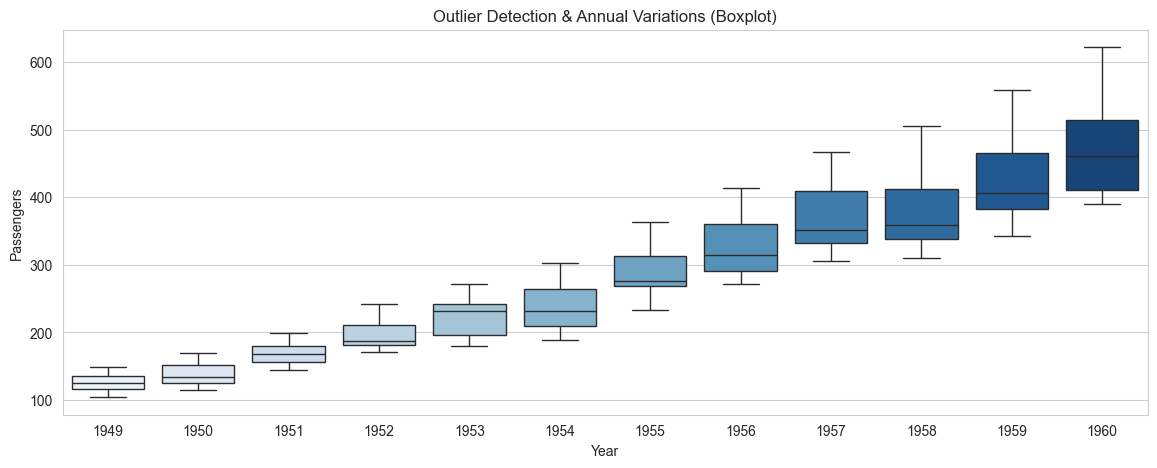

In [20]:

df_diagnostics['Year'] = df_diagnostics.index.year
df_diagnostics['Month_Name'] = df_diagnostics.index.strftime('%b')

# Boxplot across years
plt.figure(figsize=(14, 5))
sns.boxplot(x='Year', y='Passengers', data=df_diagnostics, palette="Blues")
plt.title("Outlier Detection & Annual Variations (Boxplot)")
plt.show()

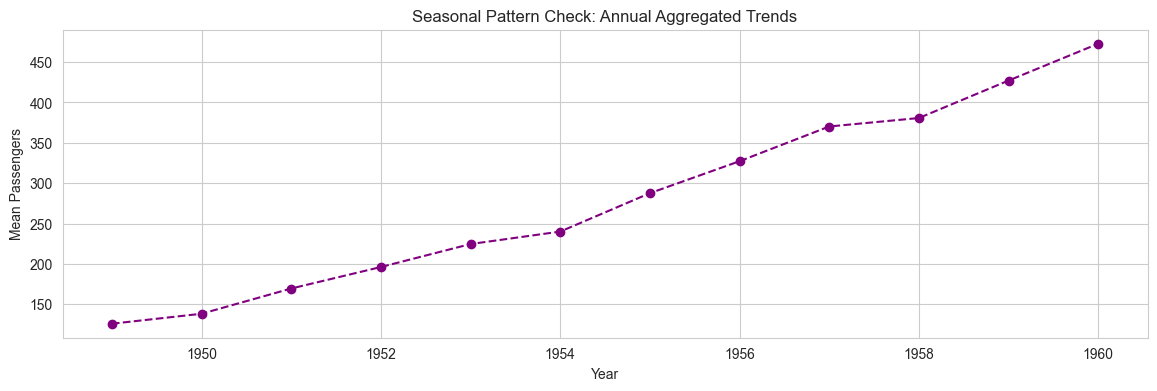

In [21]:
# Seasonal Pattern Check via annual aggregated trends
annual_data = df_diagnostics.groupby('Year')['Passengers'].mean()
plt.figure(figsize=(14, 4))
plt.plot(annual_data, marker='o', color='purple', linestyle='--')
plt.title("Seasonal Pattern Check: Annual Aggregated Trends")
plt.xlabel("Year")
plt.ylabel("Mean Passengers")
plt.grid(True)
plt.show()

In [22]:
# --- Stationarity Summary: ADF Test ---
from statsmodels.tsa.stattools import adfuller

adf_stat, p_value, _, _, critical_values, _ = adfuller(series)

print("ADF Test Results:")
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print("Critical Values:", critical_values)


ADF Test Results:
ADF Statistic: 0.9030
P-value: 0.9931
Critical Values: {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}


## 10. Trend & Seasonality Decomposition

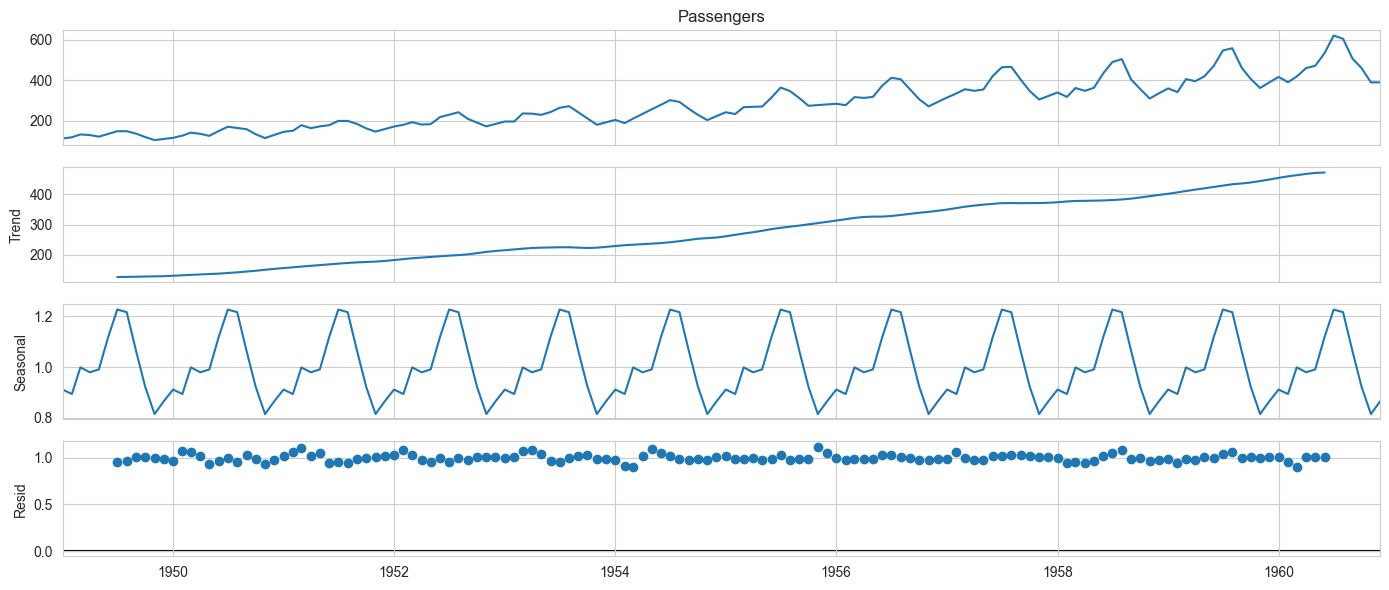

In [23]:
## Classical Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    series,
    model='multiplicative',
    period=12
)

decomposition.plot()
plt.show()

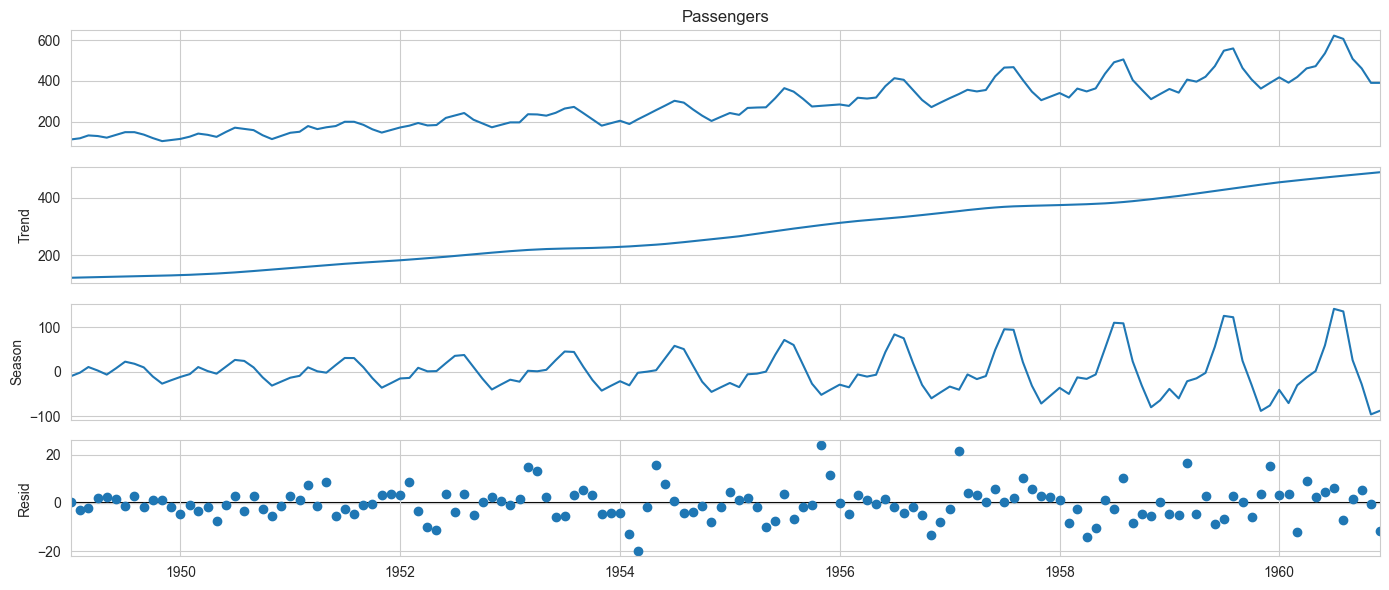

In [24]:
## STL Decomposition
from statsmodels.tsa.seasonal import STL

stl = STL(series, period=12)

result = stl.fit()

result.plot()
plt.show()

Classical decomposition assumes fixed seasonality.

STL allows changing seasonal patterns and is more robust.

## 10. Rolling Statistics

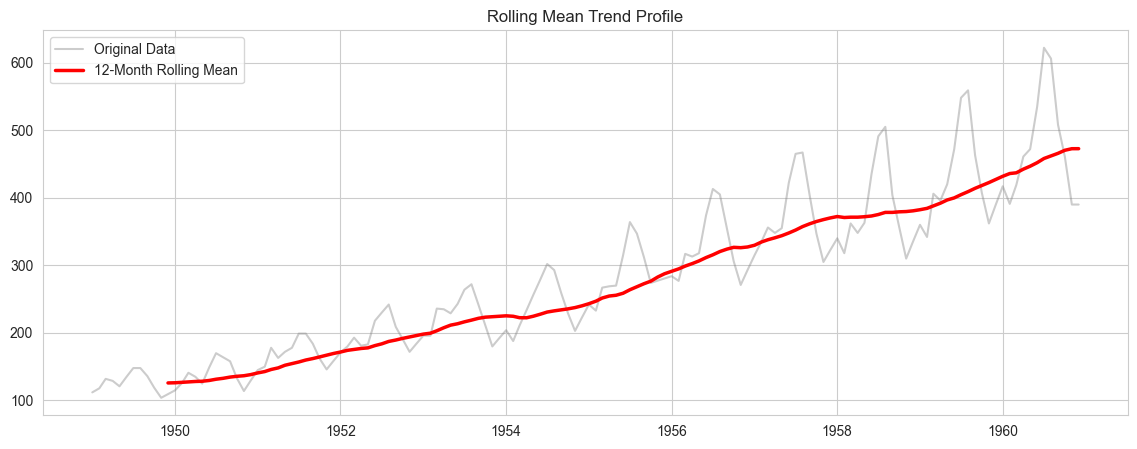

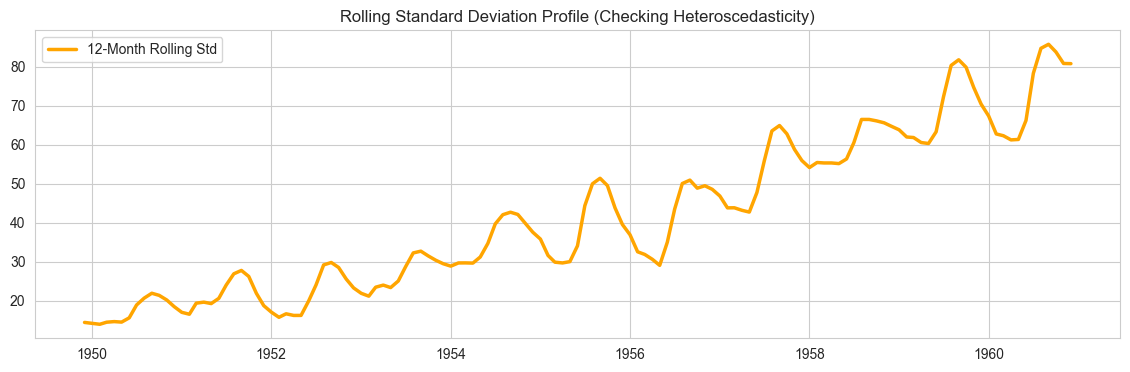

In [25]:
rolling_mean = series.rolling(window=12).mean()
rolling_std = series.rolling(window=12).std()

plt.figure(figsize=(14, 5))
plt.plot(series, label="Original Data", alpha=0.4, color='gray')
plt.plot(rolling_mean, label="12-Month Rolling Mean", linewidth=2.5, color='red')
plt.title("Rolling Mean Trend Profile")
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(rolling_std, label="12-Month Rolling Std", linewidth=2.5, color='orange')
plt.title("Rolling Standard Deviation Profile (Checking Heteroscedasticity)")
plt.legend()
plt.show()

## 11. Dependency & Memory Diagnostics

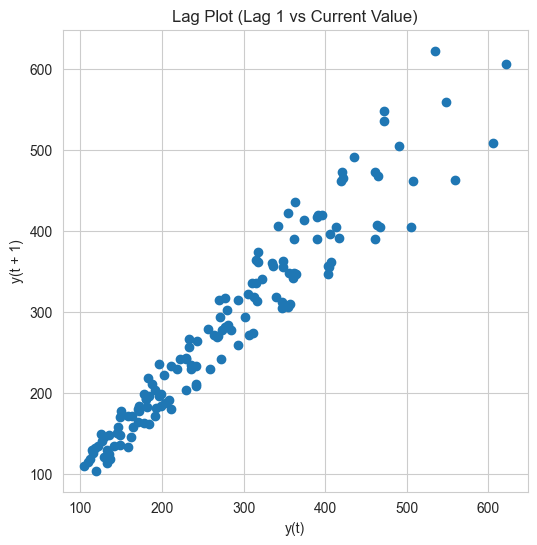

In [26]:
# Lag Plot
plt.figure(figsize=(6, 6))
lag_plot(series, lag=1)
plt.title("Lag Plot (Lag 1 vs Current Value)")
plt.show()



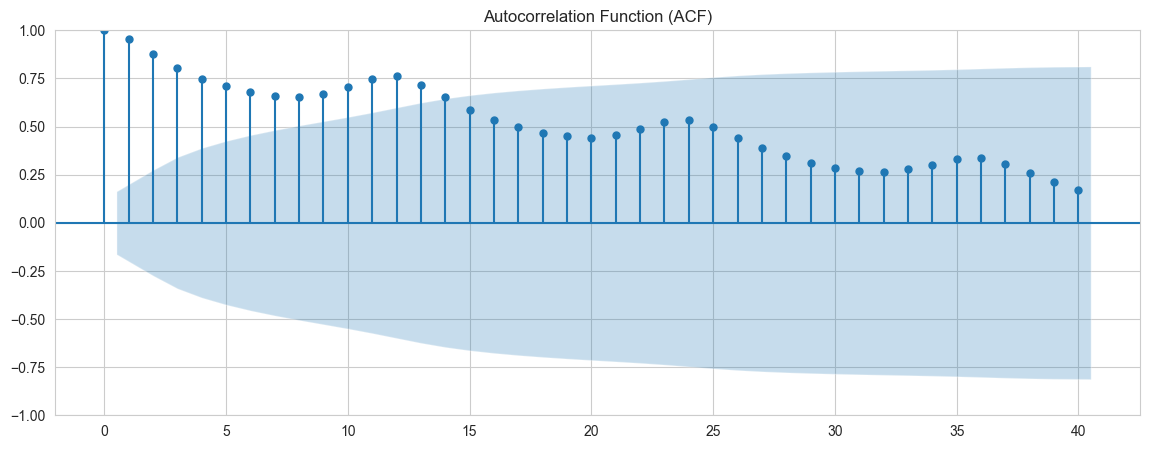

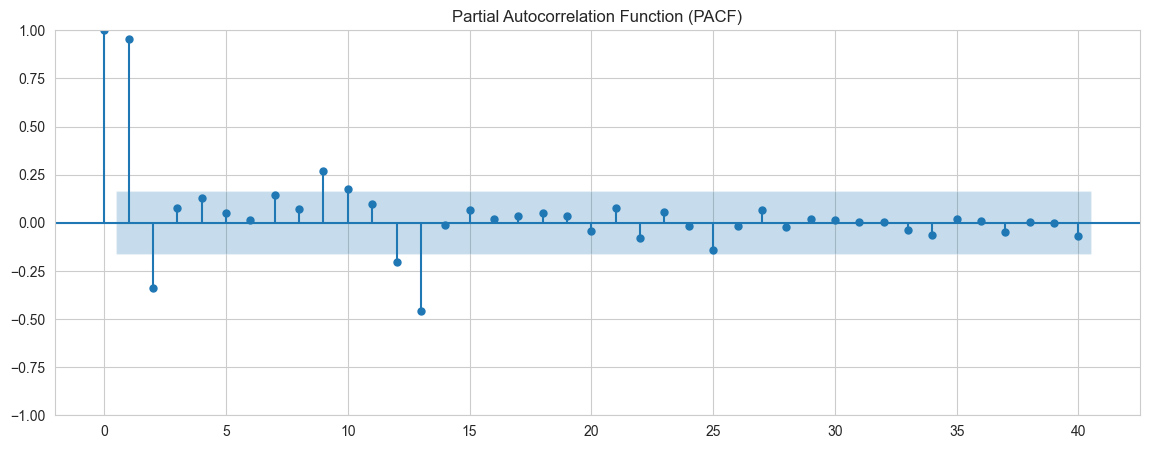

In [27]:
# ACF Plot
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(series, lags=40, ax=ax)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# PACF Plot
fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(series, lags=40, method='ywm', ax=ax)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()